** Data Extraction **

In [ ]:
import requests
import pandas as pd

# Get the latest block height
latest_block_url = "https://api.blockchair.com/bitcoin/blocks?limit=1"
block_response = requests.get(latest_block_url)

if block_response.status_code == 200:
    block_data = block_response.json()['data'][0]
    block_id = block_data['id']  # Get block height

    # Get transactions from that block
    tx_url = f"https://api.blockchair.com/bitcoin/raw/block/{block_id}"
    tx_response = requests.get(tx_url)

    if tx_response.status_code == 200:
        raw_block = tx_response.json()['data'][str(block_id)]['decoded_raw_block']
        transactions = raw_block['tx']
        op_return_txs = []

        for tx in transactions:
            for vout in tx.get('vout', []):
                script = vout.get('scriptPubKey', {}).get('asm', '')
                if script.startswith('OP_RETURN'):
                    tx_info = {
                        "Transaction Hash": tx.get('txid'),
                        "Time": block_data.get("time"),
                        "OP_RETURN Data": script,
                        "Value (BTC)": vout.get("value")
                    }
                    op_return_txs.append(tx_info)

        df = pd.DataFrame(op_return_txs)
        print(df)
    else:
        print("❌ Failed to fetch transaction data from block.")
else:
    print("❌ Failed to fetch latest block.")


❌ Failed to fetch latest block.


** Decode OP_RETURN Messages **

In [ ]:
!pip install requests pandas nltk

import requests
import pandas as pd
import re
import nltk
nltk.download('punkt')
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# ----------------------
# Function to decode OP_RETURN message
# ----------------------
def decode_op_return(tx_hash):
    # Get raw transaction hex
    hex_url = f"https://blockstream.info/api/tx/{tx_hash}/hex"
    raw_response = requests.get(hex_url)

    if raw_response.status_code != 200:
        return "[Raw TX fetch failed]"

    # Decode raw hex using Blockstream decode API
    decode_url = "https://blockstream.info/api/tx/decode"
    decode_response = requests.post(decode_url, data=raw_response.text)

    if decode_response.status_code != 200:
        return "[Decode failed]"

    decoded_tx = decode_response.json()

    for vout in decoded_tx.get("vout", []):
        script = vout.get("scriptpubkey_asm", "")
        if "OP_RETURN" in script:
            hex_msg = script.split("OP_RETURN ")[-1]
            try:
                decoded = bytes.fromhex(hex_msg).decode('utf-8', errors='ignore')
                return decoded
            except:
                return "[Hex decode error]"

    return "[No OP_RETURN found]"

# ----------------------
# Text cleaning and standardizing
# ----------------------
def clean_text(text):
    # Lowercase, remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text.lower())

    # Replace common slang (example)
    slang_dict = {
        "u": "you",
        "r": "are",
        "lol": "laugh",
        "pls": "please",
        "thx": "thanks",
    }

    words = text.split()
    words = [slang_dict.get(w, w) for w in words]  # Replace slang

    # Remove stopwords
    filtered = [w for w in words if w not in stopwords.words('english')]
    return ' '.join(filtered)

# ----------------------
# Step 1: Fetch OP_RETURN TX hashes
# ----------------------
url = "https://api.blockchair.com/bitcoin/transactions?q=is_op_return(true)&limit=100"
response = requests.get(url)

if response.status_code == 200:
    data = response.json()
    tx_data = data['data']

    tx_list = []

    for tx in tx_data:
        tx_hash = tx.get("transaction_hash")
        op_text = decode_op_return(tx_hash)
        cleaned = clean_text(op_text)

        tx_list.append({
            "Transaction Hash": tx_hash,
            "Time": tx.get("time"),
            "OP_RETURN Message": op_text,
            "Cleaned Message": cleaned
        })

    df = pd.DataFrame(tx_list)
    print(df)
else:
    print("Failed to fetch data.")

# Dictionary of common slang and abbreviations
slang_dict = {
    "u": "you",
    "r": "are",
    "pls": "please",
    "thx": "thanks",
    "idk": "i do not know",
    "imo": "in my opinion",
    "btw": "by the way",
    "lol": "laugh out loud",
    "omg": "oh my god",
    "brb": "be right back",
    "lmk": "let me know",
    "smh": "shaking my head"
}

# Function to clean and standardize text
def clean_and_standardize(text):
    if not isinstance(text, str):
        return ""

    # Lowercase the text
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Remove special characters and numbers (keep only letters and spaces)
    text = re.sub(r'[^a-z\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Replace slang with full form
    words = text.split()
    words = [slang_dict.get(word, word) for word in words]

    # Join cleaned words
    cleaned_text = ' '.join(words)
    return cleaned_text
    return cleaned_text



[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Failed to fetch data.


In [ ]:

import requests

# ✅ Replace these with your actual values
wallet_address = "5oCpbxHqboNTzDqKPiSC5yXEYFDip2xC6ADa8a9zUoLr"
api_key = "your_real_helius_api_key_here"

# ✅ Construct the API URL
url = f"https://api.helius.xyz/v0/addresses/{wallet_address}/transactions?api-key={api_key}&limit=50"

# ✅ Send the request
response = requests.get(url)

# ✅ Handle the response
if response.status_code == 200:
    transactions = response.json()

    print("🔍 On-Chain Memos found:\n")
    found = False
    for tx in transactions:
        for instr in tx.get("instructions", []):
            if instr.get("program") == "spl-memo":
                print("📩 Memo Message:", instr.get("data"))
                found = True
    if not found:
        print("⚠️ No memos found in these transactions.")
else:
    print(f"❌ Error fetching data: {response.status_code}")
    print("🔧 Response content:", response.text)  # Help debug

import requests
import re

# ✅ Replace with your actual Helius API key
wallet_address = "5oCpbxHqboNTzDqKPiSC5yXEYFDip2xC6ADa8a9zUoLr"
api_key = "your_real_helius_api_key_here"

url = f"https://api.helius.xyz/v0/addresses/{wallet_address}/transactions?api-key={api_key}&limit=50"
response = requests.get(url)

# ✅ Slang and abbreviation dictionary
slang_dict = {
    "u": "you",
    "r": "are",
    "pls": "please",
    "plz": "please",
    "thx": "thanks",
    "idk": "i don't know",
    "imo": "in my opinion",
    "btw": "by the way",
    "lol": "laugh out loud",
    "omg": "oh my god",
    "brb": "be right back",
    "lmk": "let me know",
    "smh": "shaking my head",
    "ty": "thank you",
    "np": "no problem",
    "asap": "as soon as possible"
}

# ✅ Clean and standardize function
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()  # Lowercase
    text = re.sub(r"http\S+|www\S+", "", text)  # Remove URLs
    text = re.sub(r"[^a-z\s]", "", text)  # Remove special chars and numbers
    text = re.sub(r"\s+", " ", text).strip()  # Remove extra spaces
    words = text.split()
    # Replace slang
    words = [slang_dict.get(word, word) for word in words]
    return " ".join(words)

# ✅ Process and display memo messages
if response.status_code == 200:
    transactions = response.json()
    print("🔍 Cleaned On-Chain Memos:\n")
    found = False
    for tx in transactions:
        for instr in tx.get("instructions", []):
            if instr.get("program") == "spl-memo":
                raw_memo = instr.get("data", "")
                cleaned_memo = clean_text(raw_memo)
                print("📩 Original:", raw_memo)
                print("✅ Cleaned: ", cleaned_memo)
                print("-" * 50)
                found = True
    if not found:
        print("⚠️ No memos found in these transactions.")
else:
    print(f"❌ Error fetching data: {response.status_code}")
    print("🔧 Response content:", response.text)



❌ Error fetching data: 401
🔧 Response content: {"jsonrpc":"2.0","error":{"code":-32401,"message":"invalid api key provided"}}
❌ Error fetching data: 401
🔧 Response content: {"jsonrpc":"2.0","error":{"code":-32401,"message":"invalid api key provided"}}


In [ ]:
import requests
import re
import matplotlib.pyplot as plt

# ✅ Replace with your real Helius API key
wallet_address = "5oCpbxHqboNTzDqKPiSC5yXEYFDip2xC6ADa8a9zUoLr"
api_key = "your_real_helius_api_key_here"

# ✅ API request
url = f"https://api.helius.xyz/v0/addresses/{wallet_address}/transactions?api-key={api_key}&limit=50"
response = requests.get(url)

# ✅ Slang and abbreviation dictionary
slang_dict = {
    "u": "you",
    "r": "are",
    "pls": "please",
    "plz": "please",
    "thx": "thanks",
    "idk": "i don't know",
    "imo": "in my opinion",
    "btw": "by the way",
    "lol": "laugh out loud",
    "omg": "oh my god",
    "brb": "be right back",
    "lmk": "let me know",
    "smh": "shaking my head",
    "ty": "thank you",
    "np": "no problem",
    "asap": "as soon as possible"
}

# ✅ Text cleaning function
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    words = text.split()
    words = [slang_dict.get(word, word) for word in words]
    return " ".join(words)

# ✅ Process memos and store lengths
original_memos = []
cleaned_memos = []

if response.status_code == 200:
    transactions = response.json()
    print("🔍 Cleaned On-Chain Memos:\n")
    found = False

    for tx in transactions:
        for instr in tx.get("instructions", []):
            if instr.get("program") == "spl-memo":
                raw_memo = instr.get("data", "")
                cleaned_memo = clean_text(raw_memo)
                original_memos.append(raw_memo)
                cleaned_memos.append(cleaned_memo)

                print("📩 Original:", raw_memo)
                print("✅ Cleaned: ", cleaned_memo)
                print("-" * 50)
                found = True

    if found and original_memos:
        # ✅ Prepare lengths for graph
        indices = list(range(len(original_memos)))
        original_lengths = [len(m) for m in original_memos]
        cleaned_lengths = [len(m) for m in cleaned_memos]

        # ✅ Plot bar graph
        plt.figure(figsize=(12, 6))
        bar_width = 0.4
        plt.bar(indices, original_lengths, width=bar_width, label='Original', alpha=0.7)
        plt.bar([i + bar_width for i in indices], cleaned_lengths, width=bar_width, label='Cleaned', alpha=0.7)
        plt.xlabel('Memo Index')
        plt.ylabel('Length (characters)')
        plt.title('Length of Original vs Cleaned On-Chain Memo Messages')
        plt.xticks([i + bar_width/2 for i in indices], [str(i+1) for i in indices], rotation=90)
        plt.legend()
        plt.tight_layout()
        plt.show()

    elif not found:
        print("⚠️ No memos found in these transactions.")
else:
    print(f"❌ Error fetching data: {response.status_code}")
    print("🔧 Response content:", response.text)


❌ Error fetching data: 401
🔧 Response content: {"jsonrpc":"2.0","error":{"code":-32401,"message":"invalid api key provided"}}


**Predictive Modeling**

In [ ]:
import pandas as pd
import numpy as np
import requests

# ------------------ 1. Fetch OP_RETURN Transactions ------------------ #
url = "https://api.blockchair.com/bitcoin/transactions?q=is_op_return(true)&limit=100"
response = requests.get(url)

if response.status_code == 200:
    data = response.json()
    tx_data = data['data']

    op_return_txs = []
    for tx in tx_data:
        tx_info = {
            "Transaction Hash": tx.get("transaction_hash"),
            "Time": tx.get("time"),
            "Size (bytes)": tx.get("size"),
            "Fee (satoshis)": tx.get("fee")
        }
        op_return_txs.append(tx_info)

    df_opreturn = pd.DataFrame(op_return_txs)
    print("✅ OP_RETURN transactions fetched:\n", df_opreturn.head())
else:
    print("❌ Failed to fetch OP_RETURN data. Status code:", response.status_code)

# ------------------ 2. Fetch Historical BTC Prices ------------------ #
# Example using CoinGecko
price_url = "https://api.coingecko.com/api/v3/coins/bitcoin/market_chart?vs_currency=usd&days=30&interval=daily"
price_response = requests.get(price_url)

if price_response.status_code == 200:
    price_data = price_response.json()['prices']

    # Convert to DataFrame
    df_price = pd.DataFrame(price_data, columns=['timestamp', 'close'])
    df_price['date'] = pd.to_datetime(df_price['timestamp'], unit='ms').dt.date

    # Compute price direction
    df_price['price_diff'] = df_price['close'].diff()
    df_price['price_direction'] = (df_price['price_diff'] > 0).astype(int)

    df_price = df_price.dropna(subset=['price_direction'])

    print("✅ BTC Price Direction:\n", df_price[['date', 'close', 'price_direction']].head())
else:
    print("❌ Failed to fetch BTC price data. Status code:", price_response.status_code)


❌ Failed to fetch OP_RETURN data. Status code: 430
✅ BTC Price Direction:
          date          close  price_direction
0  2025-06-22  101532.568385                0
1  2025-06-23  100852.582646                0
2  2025-06-24  105511.624379                1
3  2025-06-25  105976.069298                1
4  2025-06-26  107238.530450                1


In [ ]:
# Assume df_price already exists and is sorted by date
df_price = df_price.sort_values('date')  # Ensure correct order

# Define train-test split ratio (e.g., 80% train, 20% test)
train_size = int(len(df_price) * 0.8)

# Split chronologically
train_df = df_price.iloc[:train_size]
test_df = df_price.iloc[train_size:]

# Print shape summary
print(f"✅ Train shape: {train_df.shape}")
print(f"✅ Test shape: {test_df.shape}")

# Optional: check head of each
print("\n🔹 Train Sample:\n", train_df[['date', 'close', 'price_direction']].tail())
print("\n🔹 Test Sample:\n", test_df[['date', 'close', 'price_direction']].head())


✅ Train shape: (24, 5)
✅ Test shape: (7, 5)

🔹 Train Sample:
           date          close  price_direction
19  2025-07-11  115879.650301                1
20  2025-07-12  117571.025100                1
21  2025-07-13  117418.957450                0
22  2025-07-14  119117.556663                1
23  2025-07-15  119833.674467                1

🔹 Test Sample:
           date          close  price_direction
24  2025-07-16  117678.194934                0
25  2025-07-17  118748.162737                1
26  2025-07-18  119445.365204                1
27  2025-07-19  117988.946645                0
28  2025-07-20  117901.626559                0


**Train & Compare Models**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# -----------------------------
# Step 1: Feature Engineering
# -----------------------------

# Use past price-based features
def add_features(df):
    df = df.copy()
    df['return'] = df['close'].pct_change()
    df['ma_3'] = df['close'].rolling(3).mean()
    df['ma_7'] = df['close'].rolling(7).mean()
    df['volatility'] = df['return'].rolling(3).std()
    df = df.dropna()
    return df

df_price = add_features(df_price)

# Re-split after feature engineering
df_price = df_price.sort_values('date')
train_size = int(len(df_price) * 0.8)
train_df = df_price.iloc[:train_size]
test_df = df_price.iloc[train_size:]

# Features and target
feature_cols = ['return', 'ma_3', 'ma_7', 'volatility']
target_col = 'price_direction'

X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_test = test_df[feature_cols]
y_test = test_df[target_col]

# -----------------------------
# Step 2: Train Models
# -----------------------------

models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "SVM": SVC(kernel='rbf', probability=True),
    "Logistic Regression": LogisticRegression(max_iter=1000)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results[name] = {
        'Accuracy': acc,
        'F1 Score': f1,
        'Report': classification_report(y_test, y_pred, output_dict=True)
    }
    print(f"\n🔹 {name} Classification Report:")
    print(classification_report(y_test, y_pred))

# -----------------------------
# Step 3: Comparison Summary
# -----------------------------

summary_df = pd.DataFrame({model: {'Accuracy': metrics['Accuracy'], 'F1 Score': metrics['F1 Score']}
                           for model, metrics in results.items()}).T

print("\n✅ Model Comparison Summary:")
print(summary_df.sort_values(by="F1 Score", ascending=False))



🔹 Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         2

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:51:08] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



🔹 XGBoost Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         2

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5


🔹 SVM Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.40      1.00      0.57         2

    accuracy                           0.40         5
   macro avg       0.20      0.50      0.29         5
weighted avg       0.16      0.40      0.23         5


🔹 Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.40      1.00      0.57         2

    accuracy                           0.40         5
   macro avg      

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m


🔹 Random Forest Metrics:
Accuracy: 0.750, F1 Score: 0.667, ROC-AUC: 1.000
              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       0.50      1.00      0.67         1

    accuracy                           0.75         4
   macro avg       0.75      0.83      0.73         4
weighted avg       0.88      0.75      0.77         4



/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:52:52] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in 


🔹 XGBoost Metrics:
Accuracy: 0.250, F1 Score: 0.400, ROC-AUC: 1.000
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.25      1.00      0.40         1

    accuracy                           0.25         4
   macro avg       0.12      0.50      0.20         4
weighted avg       0.06      0.25      0.10         4


🔹 SVM Metrics:
Accuracy: 0.250, F1 Score: 0.400, ROC-AUC: 0.333
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.25      1.00      0.40         1

    accuracy                           0.25         4
   macro avg       0.12      0.50      0.20         4
weighted avg       0.06      0.25      0.10         4


🔹 Logistic Regression Metrics:
Accuracy: 0.250, F1 Score: 0.400, ROC-AUC: 0.667
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.2

/tmp/ipython-input-6-1200831394.py:108: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


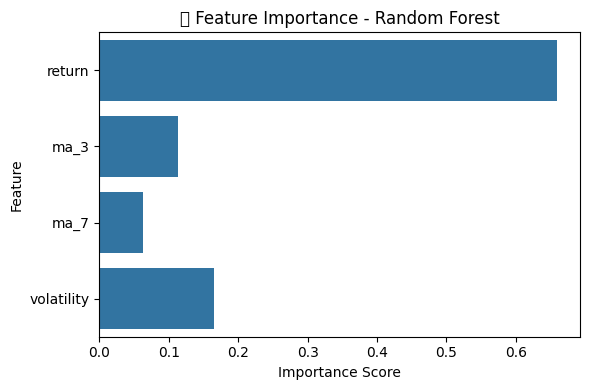

/tmp/ipython-input-6-1200831394.py:108: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


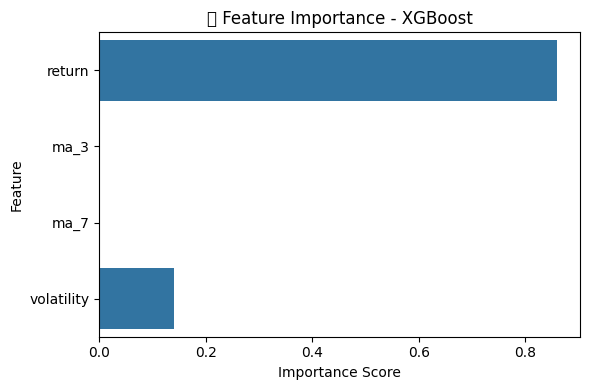

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error
)
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Step 1: Feature Engineering
# -----------------------------

def add_features(df):
    df = df.copy()
    df['return'] = df['close'].pct_change()
    df['ma_3'] = df['close'].rolling(3).mean()
    df['ma_7'] = df['close'].rolling(7).mean()
    df['volatility'] = df['return'].rolling(3).std()
    df = df.dropna()
    return df

df_price = add_features(df_price)
df_price = df_price.sort_values('date')

# -----------------------------
# Step 2: Train-Test Split
# -----------------------------

train_size = int(len(df_price) * 0.8)
train_df = df_price.iloc[:train_size]
test_df = df_price.iloc[train_size:]

feature_cols = ['return', 'ma_3', 'ma_7', 'volatility']
target_col = 'price_direction'

X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_test = test_df[feature_cols]
y_test = test_df[target_col]

# -----------------------------
# Step 3: Model Training and Evaluation
# -----------------------------

models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "SVM": SVC(kernel='rbf', probability=True),
    "Logistic Regression": LogisticRegression(max_iter=1000)
}

results = {}
feature_importances = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan

    results[name] = {
        'Accuracy': acc,
        'F1 Score': f1,
        'ROC-AUC': roc,
        'Classification Report': classification_report(y_test, y_pred)
    }

    print(f"\n🔹 {name} Metrics:")
    print(f"Accuracy: {acc:.3f}, F1 Score: {f1:.3f}, ROC-AUC: {roc:.3f}")
    print(classification_report(y_test, y_pred))

    # Feature importance (if supported)
    if hasattr(model, 'feature_importances_'):
        feature_importances[name] = pd.Series(model.feature_importances_, index=feature_cols)

# -----------------------------
# Step 4: Compare Models
# -----------------------------

summary = pd.DataFrame({model: {
    'Accuracy': metrics['Accuracy'],
    'F1 Score': metrics['F1 Score'],
    'ROC-AUC': metrics['ROC-AUC']
} for model, metrics in results.items()}).T

print("\n✅ Comparison Summary:")
print(summary.sort_values(by="F1 Score", ascending=False))

# -----------------------------
# Step 5: Plot Feature Importance
# -----------------------------

for model_name, importances in feature_importances.items():
    plt.figure(figsize=(6, 4))
    sns.barplot(x=importances.values, y=importances.index)
    plt.title(f'🔍 Feature Importance - {model_name}')
    plt.xlabel("Importance Score")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()
